In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_soap=True)
molecules = qm9.get_molecules()
df = qm9.load()

2026-04-15 15:17:30.475 | INFO     | src.datasets:load:493 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-15 15:17:30.760 | INFO     | src.datasets:_sample_qm9_df:685 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-15 15:17:30.761 | INFO     | src.datasets:_add_requested_descriptors:126 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-04-15 15:17:30.761 | INFO     | src.features:compute_soap:162 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-04-15 15:18:08.012 | SUCCESS  | src.datasets:add_soap:839 - Added SOAP embeddings.
2026-04-15 15:18:08.012 | INFO     | src.datasets:_add_requested_descriptors:149 - Added descriptor column(s): ['soap_embedding']
2026-04-15 15:18:08.065 | INFO     | src.datasets:_drop_rows_with_null_required_descriptors:578 - Dropped QM9 rows with null/empty descriptor vectors: dropped=23, remaining=5477, descriptor_cols=['soap_embedding'].
2026-04-15 1

In [4]:
len(molecules[0:2])

2

In [5]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="soap",
    dist_type="soap_kernel",
)

2026-04-15 15:19:09.000 | INFO     | src.distance:get_matrix:28 - Loading cached distance matrix from data/QM9/dist_soap_soap_kernel.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples:   0%|          | 0/10 [00:00<?, ?it/s]2026-04-15 15:19:57.610 | WARNING  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:697 - DBSCAN failed for eps=0.1, min_samples=2: Negative values in data passed to X.
2026-04-15 15:19:57.622 | WARNING  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:697 - DBSCAN failed for eps=0.1, min_samples=3: Negative values in data passed to X.
2026-04-15 15:19:57.633 | WARNING  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:697 - DBSCAN failed for eps=0.1, min_samples=5: Negative values in data passed to X.
2026-04-15 15:19:57.645 | WARNING  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:697 - DBSCAN failed for eps=0.1, min_samples=8: Negative values in data passed to X.
2026-04-15 15:19:57.656 | WARNING  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:697 - DBSCAN failed for eps=0.1, min_samples=10: Negative values in data passed to X.


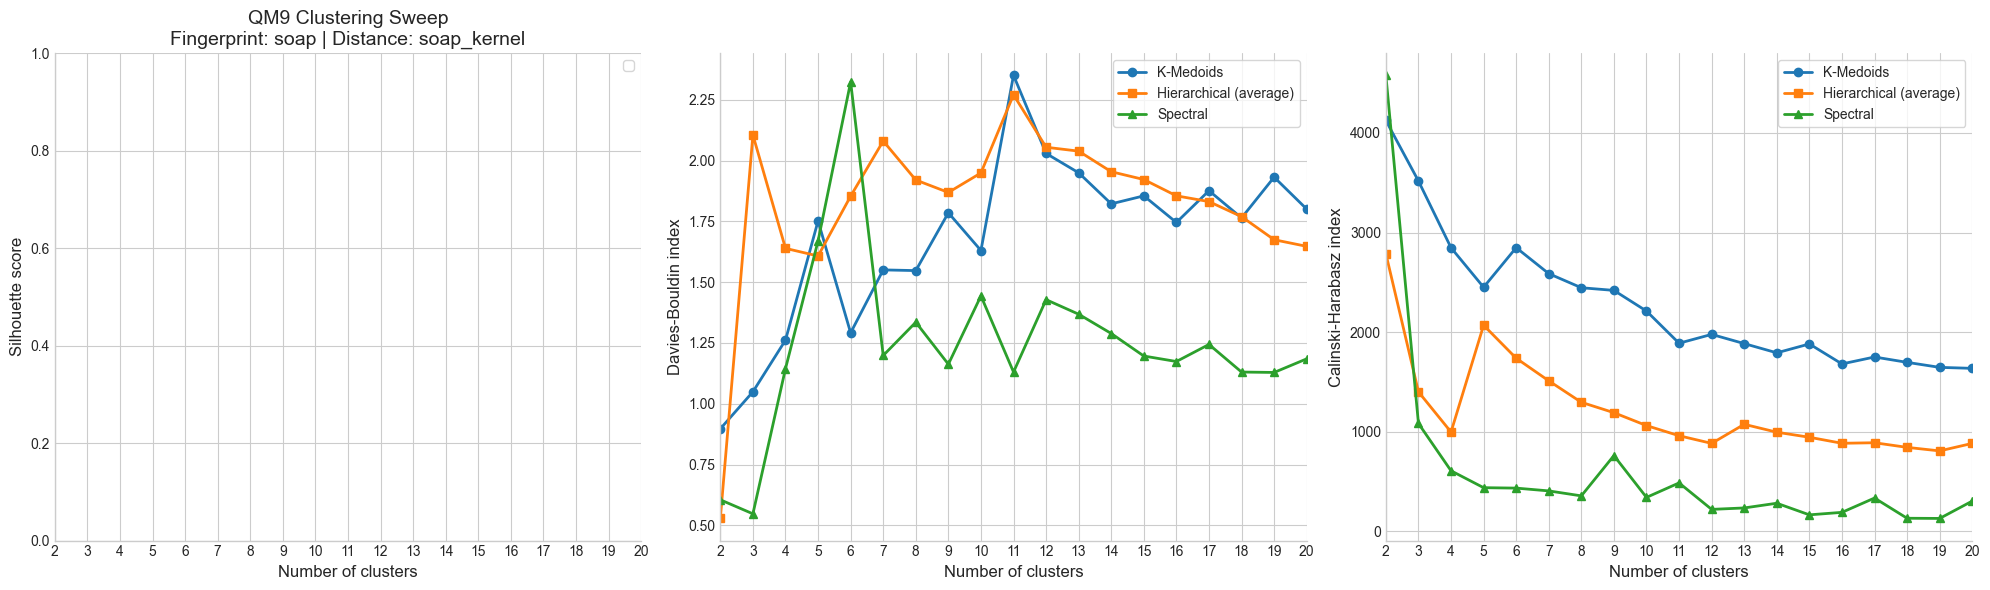

2026-04-15 15:19:58.555 | WARNING  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:818 - No valid DBSCAN parameter combinations produced clusterings to plot.
2026-04-15 15:19:58.559 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:840 - Saved clustering sweep plot to figures/qm9/clustering/soap_kernel/soap/clustering_sweep_2_to_20_clusters.png
2026-04-15 15:19:58.559 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved clustering sweep results to figures/qm9/clustering/soap_kernel/soap/clustering_sweep_2_to_20_clusters.json


In [7]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    dataset_name="qm9",
)

In [8]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(1332), np.int64(1333)), (np.int64(1128), np.int64(1129)), (np.int64(1030), np.int64(1033)), (np.int64(1073), np.int64(1075)), (np.int64(809), np.int64(810)), (np.int64(201), np.int64(354)), (np.int64(208), np.int64(209)), (np.int64(1176), np.int64(1180)), (np.int64(1429), np.int64(1430)), (np.int64(1216), np.int64(1243))]


In [9]:
print(mols[0])

(Atoms(symbols='H3CH3NHOCNCNC2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3CH3NHOCNCNC2', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [10]:
plot_molecules_with_py3dmol(mols[2])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

In [11]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1, 2, 3]), array([2423,  355, 2180,   42]))


In [12]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [13]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-15 15:20:22.062 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_hierarchical_projection.png


{'coords': array([[-1.0800362 ,  0.42017284],
        [-4.812592  ,  1.9397496 ],
        [-6.208149  ,  2.5843897 ],
        ...,
        [ 0.07301881, -0.16671704],
        [ 0.49978322,  0.00927692],
        [ 0.37725785, -0.38866594]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'hierarchical'}

In [14]:
average_numeric_by_cluster(df, "labels_hier")

labels_hier,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,2423,2.201913,19.871234,124.747833,0.179942,28.212134,0.915088,12.823548,8.89352,2.073463,0.003302,2.095344,2.384647,0.024219,0.087919,0.887862,0.872472,1.623607,7.197276,0.173752,0.601321,6.163434,6.17953,43.770532,1.264088,0.0,0.441601,0.0,0.081717,0.055716,0.001238,0.027239,0.111845,0.626496,0.0,1.955014,2.209511,77.909777,-6.512038,0.890424,7.402478,1153.96827,4.629675,-11048.683098,-11048.449324,-11048.423635,-11049.587117,32.942312,-82.437192,-82.969278,-83.454327,-76.615682,2.870152,1.473838,1.208484,94.552208,0.330169,5.117623
1,355,1.76231,13.523944,113.495775,0.025352,49.107042,0.723644,12.874539,8.24507,0.946479,0.729577,1.991826,1.405634,0.179333,0.606888,0.213779,0.949296,2.673239,4.814085,1.070423,2.850704,1.140845,6.456338,23.957746,1.25846,0.002817,0.109859,0.132394,0.250704,0.112676,0.002817,0.03662,0.101408,0.208451,0.002817,3.183099,3.198879,68.023521,-6.448416,-0.774252,5.674248,1121.159224,2.728619,-10865.867691,-10865.660869,-10865.635149,-10866.754968,27.124085,-60.763035,-61.077462,-61.399309,-56.817331,5.448308,1.484099,1.128943,14.647887,66.197183,19.15493
2,2180,2.04,17.273394,121.975688,-0.002294,41.913761,0.855653,12.843162,8.738532,1.328899,0.140826,2.033592,2.420183,0.100877,0.260377,0.638746,0.955046,2.201376,6.105963,0.659174,1.516514,3.922477,6.519725,35.336697,1.260215,0.002752,0.31789,0.033486,0.179817,0.205963,0.001835,0.056881,0.149541,0.541284,0.0,2.640367,3.014697,74.097294,-6.584297,-0.010667,6.573594,1240.666841,3.812583,-11249.415745,-11249.179056,-11249.153366,-11250.339014,31.635984,-73.617001,-74.046064,-74.464314,-68.575506,3.587597,1.288136,1.022344,69.816514,14.082569,16.100917
3,42,2.114672,13.785714,104.97619,-0.333333,34.071429,0.911277,12.799629,7.52381,2.833333,0.0,2.199308,0.785714,0.035034,0.115873,0.849093,0.880952,2.047619,5.357143,0.214286,0.547619,4.357143,4.952381,29.214286,1.284261,0.0,0.428571,0.0,0.02381,0.095238,0.0,0.071429,0.190476,0.809524,0.0,2.404762,2.576717,58.064524,-6.647288,0.587312,7.23473,690.077776,2.952242,-9916.84232,-9916.678746,-9916.652937,-9917.654448,23.358595,-59.033325,-59.400817,-59.729414,-55.023578,4.552525,2.599859,2.190483,100.0,0.0,0.0


# KMedoids

In [15]:
model_km = KMedoids(n_clusters=4, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2, 3], dtype=uint64), array([ 655, 1288, 1393, 1664]))


In [16]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [17]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-15 15:20:42.980 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_kmedoids_projection.png


{'coords': array([[-1.0800362 ,  0.42017284],
        [-4.812592  ,  1.9397496 ],
        [-6.208149  ,  2.5843897 ],
        ...,
        [ 0.07301881, -0.16671704],
        [ 0.49978322,  0.00927692],
        [ 0.37725785, -0.38866594]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'kmedoids'}

In [18]:
average_numeric_by_cluster(df, "labels_km")

labels_km,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,655,1.82498,14.381679,115.719084,0.033588,50.09771,0.745357,12.886245,8.358779,0.941985,0.621374,1.991761,1.764885,0.139815,0.575276,0.284909,1.062595,2.59542,5.230534,0.842748,2.829008,1.509924,6.50687,26.4,1.256056,0.007634,0.134351,0.141985,0.285496,0.189313,0.001527,0.045802,0.096183,0.261069,0.001527,3.177099,3.18131,69.440611,-6.367277,-0.57679,5.790562,1161.961644,2.977761,-11020.65474,-11020.438898,-11020.413196,-11021.554916,28.322631,-63.697363,-64.035834,-64.379735,-59.504016,4.981244,1.422445,1.081894,1.477863,21.679389,58.473282,19.847328
1,1288,2.171528,17.131211,120.80823,-0.236801,33.835404,0.906735,12.797245,8.675466,2.611025,0.0,2.153184,1.237578,0.044934,0.1097,0.845366,0.90528,1.95264,6.560559,0.288043,0.678571,5.365683,5.75,37.266304,1.278065,0.0,0.40528,0.0,0.07764,0.06677,0.003106,0.062888,0.142081,0.755435,0.0,2.343168,2.661423,70.919821,-6.578876,0.486898,7.06581,979.421879,3.819412,-11065.183715,-11064.981986,-11064.956293,-11066.049531,28.833091,-73.023412,-73.481913,-73.896509,-67.976364,3.306958,1.697802,1.398854,0.745342,99.145963,0.0,0.854037
2,1393,2.054489,18.124192,123.603015,0.088299,39.318019,0.865825,12.846971,8.831299,1.188083,0.118449,2.018792,2.778894,0.095822,0.242112,0.662066,0.904523,2.105528,6.299354,0.639627,1.477387,4.178033,6.819095,37.35463,1.256482,0.001436,0.316583,0.019383,0.165111,0.223977,0.000718,0.048098,0.155779,0.580761,0.0,2.536253,2.855406,76.369505,-6.567643,0.112092,6.679674,1332.66574,4.061947,-11301.344845,-11301.098319,-11301.072622,-11302.284154,32.749966,-76.535291,-76.987312,-77.427438,-71.254731,3.523548,1.174205,0.931023,1.826992,69.705671,11.844939,18.44939
3,1664,2.189109,20.704327,125.778245,0.352163,28.503606,0.910801,12.83559,8.948918,1.647236,0.001202,2.05507,2.983774,0.036536,0.087499,0.875965,0.870192,1.574519,7.23137,0.260216,0.608774,6.221755,6.321514,45.370192,1.257033,0.0,0.462139,0.0,0.097957,0.063702,0.001202,0.016827,0.106971,0.51262,0.0,1.858173,2.211693,80.338642,-6.555242,0.888569,7.443804,1231.207927,4.863978,-11030.839561,-11030.588303,-11030.562618,-11031.76445,34.907891,-85.271075,-85.817795,-86.324266,-79.22417,2.686489,1.358867,1.107189,0.221154,91.165865,0.120192,8.713942


# Spectral

In [ ]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-15 09:01:50.681 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_spectral_projection.png


{'coords': array([[-1.0800362 ,  0.42017284],
        [-4.812592  ,  1.9397496 ],
        [-6.208149  ,  2.5843897 ],
        ...,
        [ 0.07301881, -0.16671704],
        [ 0.49978322,  0.00927692],
        [ 0.37725785, -0.38866594]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'spectral'}

In [ ]:
average_numeric_by_cluster(df, "labels_spectral")

Hierarchical Clustering
shape: (6, 57)
┌─────────────────┬───────┬───────────┬────────────┬──────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬──────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┬─────────────┬───────────┐
│ labels_spectral ┆ count ┆ num_atoms ┆ mol_weight ┆ logp     ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ n

# DBSCAN 

In [ ]:
model_db = DBSCAN(
    eps=0.5,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)

ValueError: Negative values in data passed to X.

In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [ ]:
average_numeric_by_cluster(df, "labels_db")